Configuration loaded:
  Wavelength: 14.99 m
  Range resolution: 5.62 m
  Facets per position: 3000
  Time bins: 3600
SHARAD CLUTTER SIMULATOR - DATA VERIFICATION

1. CHECKING FILE STRUCTURE
  mola/  ✓ EXISTS
    - megt00n000hb.img (123.8 MB)
    - megt00n000hb.lbl.txt (0.0 MB)
    - megt00n090hb.img (123.8 MB)
    - megt00n090hb.lbl.txt (0.0 MB)
    - megt00n180hb.img (123.8 MB)
    ... and 27 more files
  sharad/  ✓ EXISTS
    - s_00571601_rgram.hdr (0.0 MB)
    - s_00571601_rgram.img (21.1 MB)
    - s_00571601_rgram.lbl.txt (0.0 MB)
    - s_00571601_rgram.xml (0.0 MB)
  outputs/  ✓ EXISTS
    - cluttergram_small.npz (0.2 MB)
    - test_angle_cutoff.png (0.1 MB)
    - test_bilinear_interpolation.png (0.7 MB)
    - test_cluttergram.npz (0.0 MB)
    - test_cluttergram_analysis.png (0.1 MB)
    ... and 13 more files

2. TESTING MOLA DEM READER
Initialized global MOLA reader
  Directory: ..\data\mola\megt88n000hb.img

Reading test region (Eastern Hellas)...

GLOBAL MOLA MOSAIC READ
Reques

Traceback (most recent call last):
  File "C:\Users\rachi\AppData\Local\Temp\ipykernel_25528\4129350934.py", line 66, in <module>
    elevation, lats, lons = mola.read_elevation(lat_range, lon_range)
                            ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rachi\OneDrive\Documents\sharad_clutter_sim\notebooks\../src\data_readers.py", line 534, in read_elevation
    self._read_single_tile(
    ~~~~~~~~~~~~~~~~~~~~~~^
        tile,
        ^^^^^
        lat_range,
        ^^^^^^^^^^
        lon_range
        ^^^^^^^^^
    )
    ^
  File "c:\Users\rachi\OneDrive\Documents\sharad_clutter_sim\notebooks\../src\data_readers.py", line 301, in _read_single_tile
    raise FileNotFoundError(
        f"Could not find label for {tile_name}"
    )
FileNotFoundError: Could not find label for megt00n090hb



  Plot saved: outputs/test_sharad_radargram.png


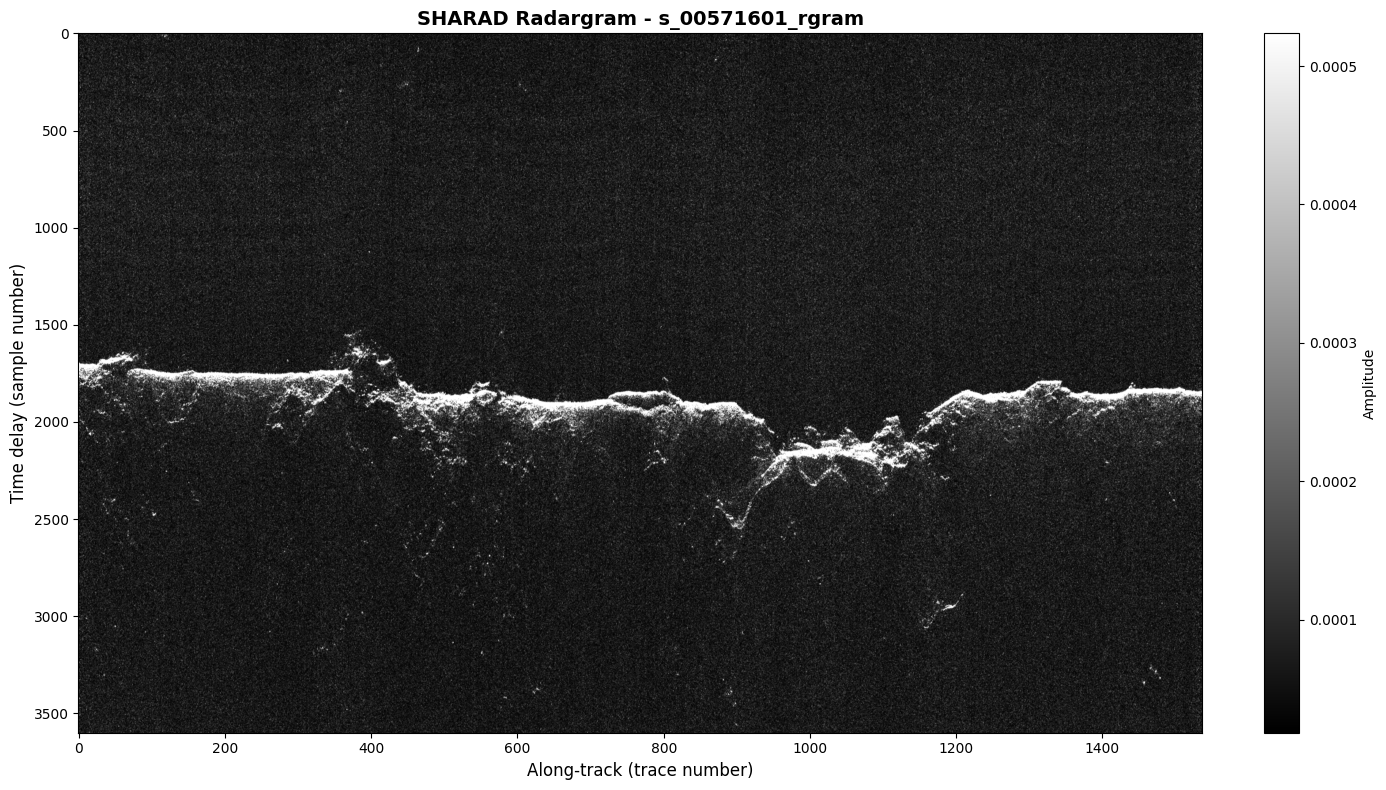


4. CHECKING XML GEOMETRY FILE

Found XML file: s_00571601_rgram.xml
Size: 11.0 KB

First 50 lines of XML (for structure inspection):
----------------------------------------------------------------------
  1: <?xml version="1.0" encoding="UTF-8"?>
  2: <?xml-model href="https://pds.nasa.gov/pds4/pds/v1/PDS4_PDS_1I00.sch" schematypens="http://purl.oclc.org/dsdl/schematron"?>
  3: <?xml-model href="https://pds.nasa.gov/pds4/mission/mro/v1/PDS4_MRO_1I00_1300.sch" schematypens="http://purl.oclc.org/dsdl/schematron"?>
  4: <?xml-model href="https://pds.nasa.gov/pds4/disp/v1/PDS4_DISP_1I00_1510.sch" schematypens="http://purl.oclc.org/dsdl/schematron" ?>
  5: <?xml-model href="https://pds.nasa.gov/pds4/geom/v1/PDS4_GEOM_1I00_1960.sch" schematypens="http://purl.oclc.org/dsdl/schematron" ?>
  6: 
  7: <Product_Observational
  8:     xmlns="http://pds.nasa.gov/pds4/pds/v1"
  9:     xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance"
 10:     xmlns:mro="http://pds.nasa.gov/pds4/mission/mro/v1"

In [1]:
"""
Data Verification Notebook
Tests that all data files are accessible and readable
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add src to path
sys.path.append('../src')

from data_readers import MOLAReader, SHARADRadargram
import config

print("="*70)
print("SHARAD CLUTTER SIMULATOR - DATA VERIFICATION")
print("="*70)

# ============================================================================
# 1. CHECK FILE STRUCTURE
# ============================================================================

print("\n" + "="*70)
print("1. CHECKING FILE STRUCTURE")
print("="*70)

data_dir = Path('../data')

# Check directories
dirs_to_check = ['mola', 'sharad', 'outputs']
for dirname in dirs_to_check:
    dir_path = data_dir / dirname
    status = "✓ EXISTS" if dir_path.exists() else "✗ MISSING"
    print(f"  {dirname}/  {status}")
    
    if dir_path.exists():
        files = list(dir_path.glob('*'))
        for f in files[:5]:  # Show first 5 files
            size_mb = f.stat().st_size / (1024 * 1024)
            print(f"    - {f.name} ({size_mb:.1f} MB)")
        if len(files) > 5:
            print(f"    ... and {len(files)-5} more files")

# ============================================================================
# 2. TEST MOLA DEM READER
# ============================================================================

print("\n" + "="*70)
print("2. TESTING MOLA DEM READER")
print("="*70)

mola_img = data_dir / 'mola' / 'megt88n000hb.img'

if mola_img.exists():
    try:
        # Initialize reader
        mola = MOLAReader(mola_img)
        
        # Read a small test region (Eastern Hellas, from paper)
        print("\nReading test region (Eastern Hellas)...")
        lat_range = (-50, -35)
        lon_range = (95, 115)
        
        elevation, lats, lons = mola.read_elevation(lat_range, lon_range)
        
        print(f"\n✓ MOLA DEM read successfully!")
        print(f"  Region: {lats.min():.1f}° to {lats.max():.1f}°N") 
        print(f"          {lons.min():.1f}° to {lons.max():.1f}°E")
        print(f"  Grid: {elevation.shape[0]} × {elevation.shape[1]} pixels")
        print(f"  Elevation: {elevation.min():.0f} to {elevation.max():.0f} m")
        
        # Plot
        fig, ax = plt.subplots(figsize=(12, 8))
        
        im = ax.imshow(elevation, 
                       extent=[lons.min(), lons.max(), lats.min(), lats.max()],
                       cmap='terrain', 
                       aspect='auto',
                       origin='upper')
        
        plt.colorbar(im, ax=ax, label='Elevation (m)', fraction=0.046)
        ax.set_xlabel('Longitude (°E)', fontsize=12)
        ax.set_ylabel('Latitude (°N)', fontsize=12)
        ax.set_title('MOLA DEM - Eastern Hellas Region\n(SHARAD Orbit 571601 Area)', 
                     fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        plt.tight_layout()
        plt.savefig(data_dir / 'outputs' / 'test_mola_dem.png', dpi=150, bbox_inches='tight')
        print(f"\n  Plot saved: outputs/test_mola_dem.png")
        plt.show()
        
    except Exception as e:
        print(f"\n✗ MOLA DEM read FAILED:")
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"\n✗ MOLA file not found: {mola_img}")

# ============================================================================
# 3. TEST SHARAD RADARGRAM READER
# ============================================================================

print("\n" + "="*70)
print("3. TESTING SHARAD RADARGRAM READER")
print("="*70)

sharad_dir = data_dir / 'sharad'
sharad_files = list(sharad_dir.glob('*rgram.img'))

if sharad_files:
    sharad_img = sharad_files[0]
    
    try:
        # Initialize reader
        sharad = SHARADRadargram(sharad_img)
        
        # Read radargram
        radargram = sharad.read_radargram()
        
        if radargram is not None:
            print(f"\n✓ SHARAD radargram read successfully!")
            print(f"  Dimensions: {radargram.shape}")
            print(f"  Value range: {radargram.min():.2e} to {radargram.max():.2e}")
            
            # Plot radargram
            fig, ax = plt.subplots(figsize=(14, 8))
            
            # Display with log scale for better visibility
            radargram_display = np.abs(radargram)
            radargram_display = np.clip(radargram_display, 
                                       np.percentile(radargram_display, 1),
                                       np.percentile(radargram_display, 99))
            
            im = ax.imshow(radargram_display,
                          aspect='auto',
                          cmap='gray',
                          interpolation='bilinear')
            
            plt.colorbar(im, ax=ax, label='Amplitude', fraction=0.046)
            ax.set_xlabel('Along-track (trace number)', fontsize=12)
            ax.set_ylabel('Time delay (sample number)', fontsize=12)
            ax.set_title(f'SHARAD Radargram - {sharad_img.stem}', 
                        fontsize=14, fontweight='bold')
            
            plt.tight_layout()
            plt.savefig(data_dir / 'outputs' / 'test_sharad_radargram.png', 
                       dpi=150, bbox_inches='tight')
            print(f"\n  Plot saved: outputs/test_sharad_radargram.png")
            plt.show()
            
        else:
            print(f"\n✗ SHARAD radargram read FAILED (returned None)")
            
    except Exception as e:
        print(f"\n✗ SHARAD radargram read FAILED:")
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"\n✗ No SHARAD radargram files found in {sharad_dir}")

# ============================================================================
# 4. XML GEOMETRY FILE INSPECTION
# ============================================================================

print("\n" + "="*70)
print("4. CHECKING XML GEOMETRY FILE")
print("="*70)

xml_files = list(sharad_dir.glob('*.xml'))

if xml_files:
    xml_file = xml_files[0]
    print(f"\nFound XML file: {xml_file.name}")
    print(f"Size: {xml_file.stat().st_size / 1024:.1f} KB")
    
    # Read first 50 lines to understand structure
    print("\nFirst 50 lines of XML (for structure inspection):")
    print("-" * 70)
    with open(xml_file, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= 50:
                break
            print(f"{i+1:3d}: {line.rstrip()}")
    print("-" * 70)
    print("\n⚠️  XML parsing will need to be customized based on this structure")
    print("    We'll implement proper parsing in Section 2")
else:
    print(f"\n⚠️  No XML files found")
    print("    Geometry will need to be extracted from label or other source")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("VERIFICATION SUMMARY")
print("="*70)

checks = {
    'MOLA DEM file': mola_img.exists() if 'mola_img' in locals() else False,
    'MOLA readable': 'elevation' in locals() and elevation is not None,
    'SHARAD file': len(sharad_files) > 0 if 'sharad_files' in locals() else False,
    'SHARAD readable': 'radargram' in locals() and radargram is not None,
    'XML geometry': len(xml_files) > 0 if 'xml_files' in locals() else False,
}

for check, passed in checks.items():
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {check:20s} {status}")

all_passed = all(checks.values())

if all_passed:
    print("\n" + "="*70)
    print("✓ ALL CHECKS PASSED - Ready for Section 2!")
    print("="*70)
else:
    print("\n" + "="*70)
    print("⚠️  Some checks failed - review errors above")
    print("="*70)

In [2]:
import sys
print(sys.executable)

c:\Users\rachi\OneDrive\Documents\sharad_clutter_sim\env\Scripts\python.exe



2. TESTING GLOBAL MOLA DEM READER
Initialized global MOLA reader
  Directory: ..\data\mola

✓ Global MOLA reader initialized

----------------------------------------------------------------------
TEST 1: Single Tile - Eastern Hellas
----------------------------------------------------------------------
Latitude range:  (-40, -35)
Longitude range: (95, 115)

GLOBAL MOLA MOSAIC READ
Requested latitude: -40.00 to -35.00
Requested longitude: 95.00 to 115.00

Intersecting tiles:
  megt00n090hb

Reading tile: megt00n090hb
  Lat range: -40.00 to -35.00
  Lon range: 95.00 to 115.00
  Shape: (641, 2561)

FINAL STITCHED DEM
Shape: (641, 2561)
Latitude range: -40.00 to -35.00
Longitude range: 95.00 to 115.00
Elevation range: -5478 to 4804 m

✓ DEM loaded successfully
  Shape: (641, 2561)
  Latitude coverage: -40.00° to -35.00°
  Longitude coverage: 95.00° to 115.00°
  Elevation range: -5478 to 4804 m

Continuity checks:
  Latitude spacing continuous: True
  Longitude spacing continuous: True

 

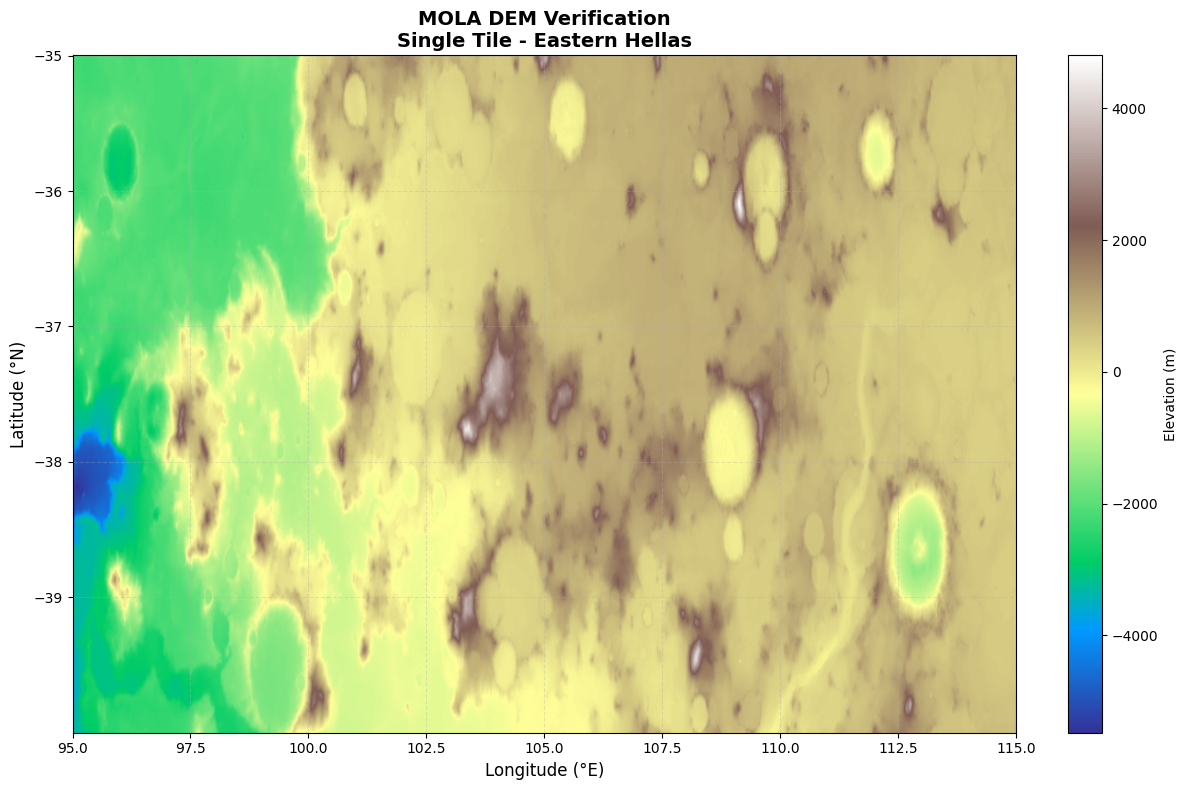


----------------------------------------------------------------------
TEST 2: Latitude Boundary Crossing
----------------------------------------------------------------------
Latitude range:  (-50, -35)
Longitude range: (95, 115)

GLOBAL MOLA MOSAIC READ
Requested latitude: -50.00 to -35.00
Requested longitude: 95.00 to 115.00

Intersecting tiles:
  megt00n090hb
  megt44s090hb

Reading tile: megt00n090hb
  Lat range: -44.00 to -35.00
  Lon range: 95.00 to 115.00
  Shape: (1153, 2561)

Reading tile: megt44s090hb
  Lat range: -50.00 to -44.00
  Lon range: 95.00 to 115.00
  Shape: (769, 2561)

FINAL STITCHED DEM
Shape: (1921, 2561)
Latitude range: -50.00 to -35.00
Longitude range: 95.00 to 115.00
Elevation range: -5478 to 4804 m

✓ DEM loaded successfully
  Shape: (1921, 2561)
  Latitude coverage: -50.00° to -35.00°
  Longitude coverage: 95.00° to 115.00°
  Elevation range: -5478 to 4804 m

Continuity checks:
  Latitude spacing continuous: True
  Longitude spacing continuous: True

  P

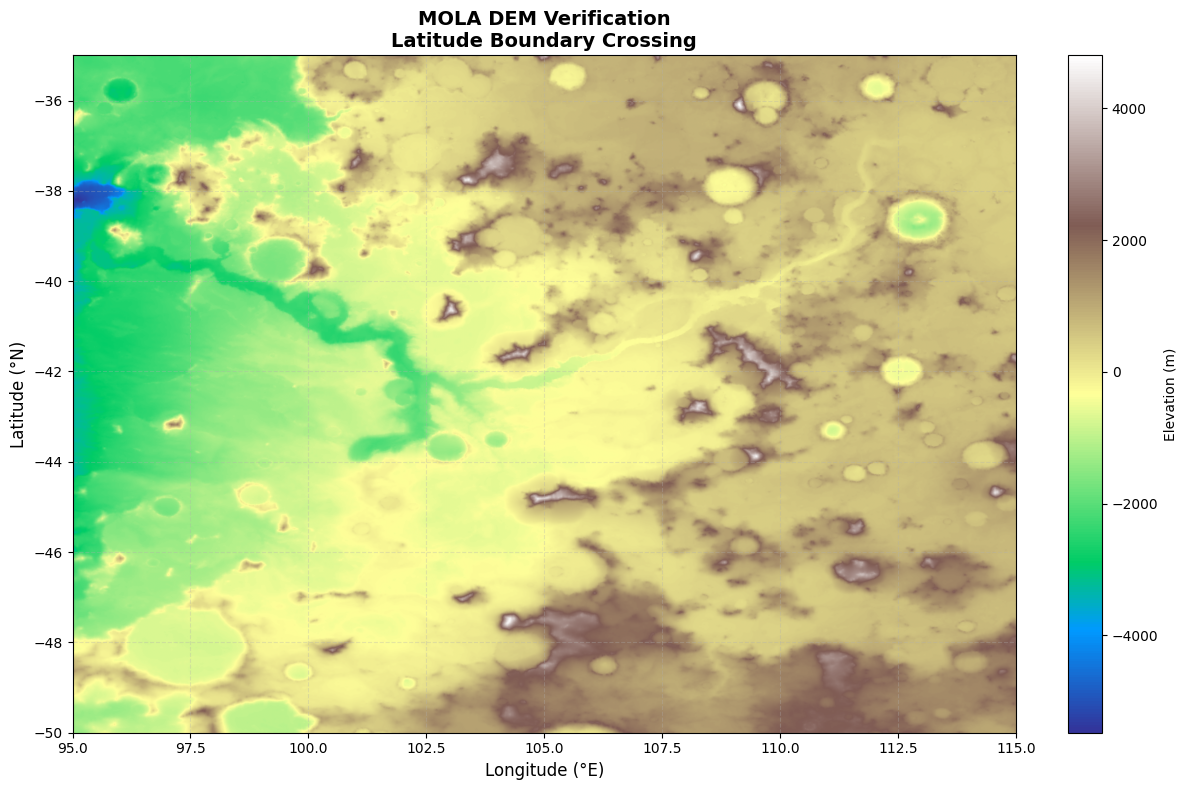


----------------------------------------------------------------------
TEST 3: Longitude Boundary Crossing
----------------------------------------------------------------------
Latitude range:  (-20, -10)
Longitude range: (85, 100)

GLOBAL MOLA MOSAIC READ
Requested latitude: -20.00 to -10.00
Requested longitude: 85.00 to 100.00

Intersecting tiles:
  megt00n000hb
  megt00n090hb

Reading tile: megt00n000hb
  Lat range: -20.00 to -10.00
  Lon range: 85.00 to 89.99
  Shape: (1281, 640)

Reading tile: megt00n090hb
  Lat range: -20.00 to -10.00
  Lon range: 90.00 to 100.00
  Shape: (1281, 1281)

FINAL STITCHED DEM
Shape: (1281, 1920)
Latitude range: -20.00 to -10.00
Longitude range: 85.00 to 100.00
Elevation range: -93 to 4686 m

✓ DEM loaded successfully
  Shape: (1281, 1920)
  Latitude coverage: -20.00° to -10.00°
  Longitude coverage: 85.00° to 100.00°
  Elevation range: -93 to 4686 m

Continuity checks:
  Latitude spacing continuous: True
  Longitude spacing continuous: False

  Plot

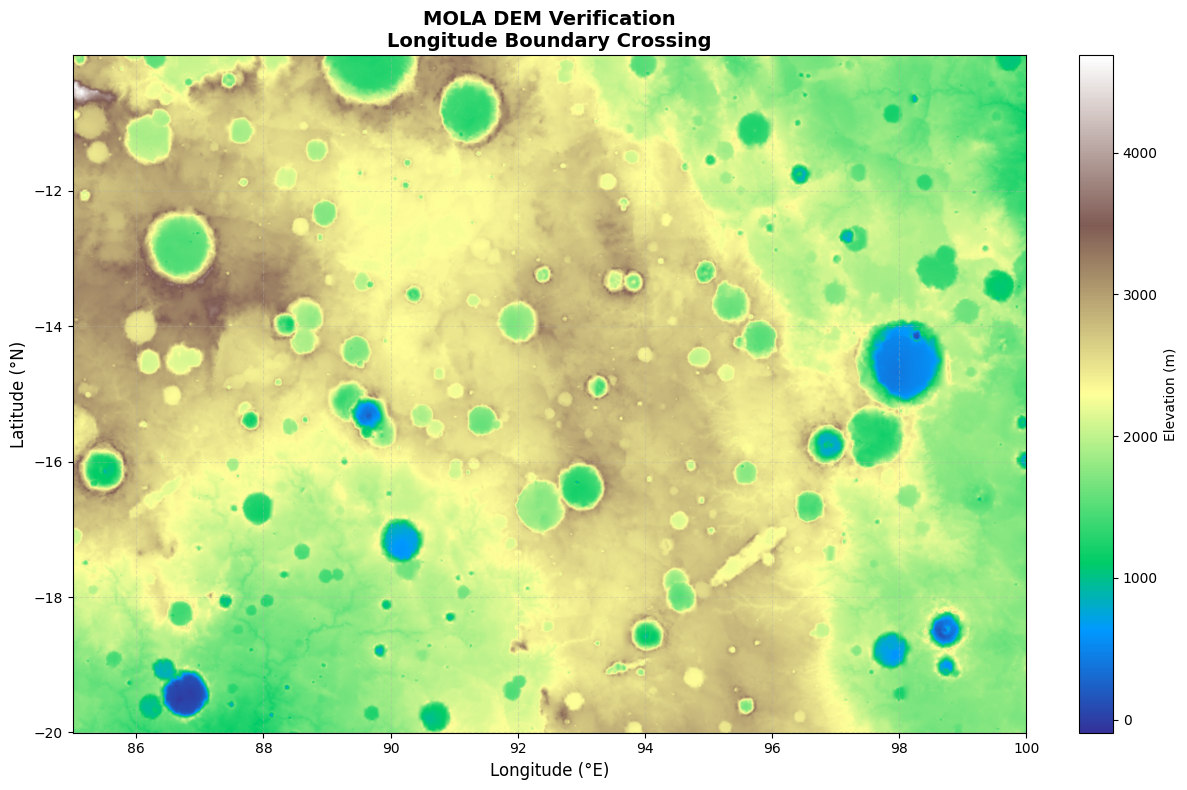


----------------------------------------------------------------------
TEST 4: 4-Tile Corner Crossing
----------------------------------------------------------------------
Latitude range:  (-50, 10)
Longitude range: (85, 100)

GLOBAL MOLA MOSAIC READ
Requested latitude: -50.00 to 10.00
Requested longitude: 85.00 to 100.00

Intersecting tiles:
  megt44n000hb
  megt44n090hb
  megt00n000hb
  megt00n090hb
  megt44s000hb
  megt44s090hb

Reading tile: megt44n000hb
  Lat range: 0.00 to 10.00
  Lon range: 85.00 to 89.99
  Shape: (1281, 640)

Reading tile: megt44n090hb
  Lat range: 0.00 to 10.00
  Lon range: 90.00 to 100.00
  Shape: (1281, 1281)

Reading tile: megt00n000hb
  Lat range: -44.00 to 0.00
  Lon range: 85.00 to 89.99
  Shape: (5632, 640)

Reading tile: megt00n090hb
  Lat range: -44.00 to 0.00
  Lon range: 90.00 to 100.00
  Shape: (5632, 1281)

Reading tile: megt44s000hb
  Lat range: -50.00 to -44.00
  Lon range: 85.00 to 89.99
  Shape: (769, 640)

Reading tile: megt44s090hb
  Lat r

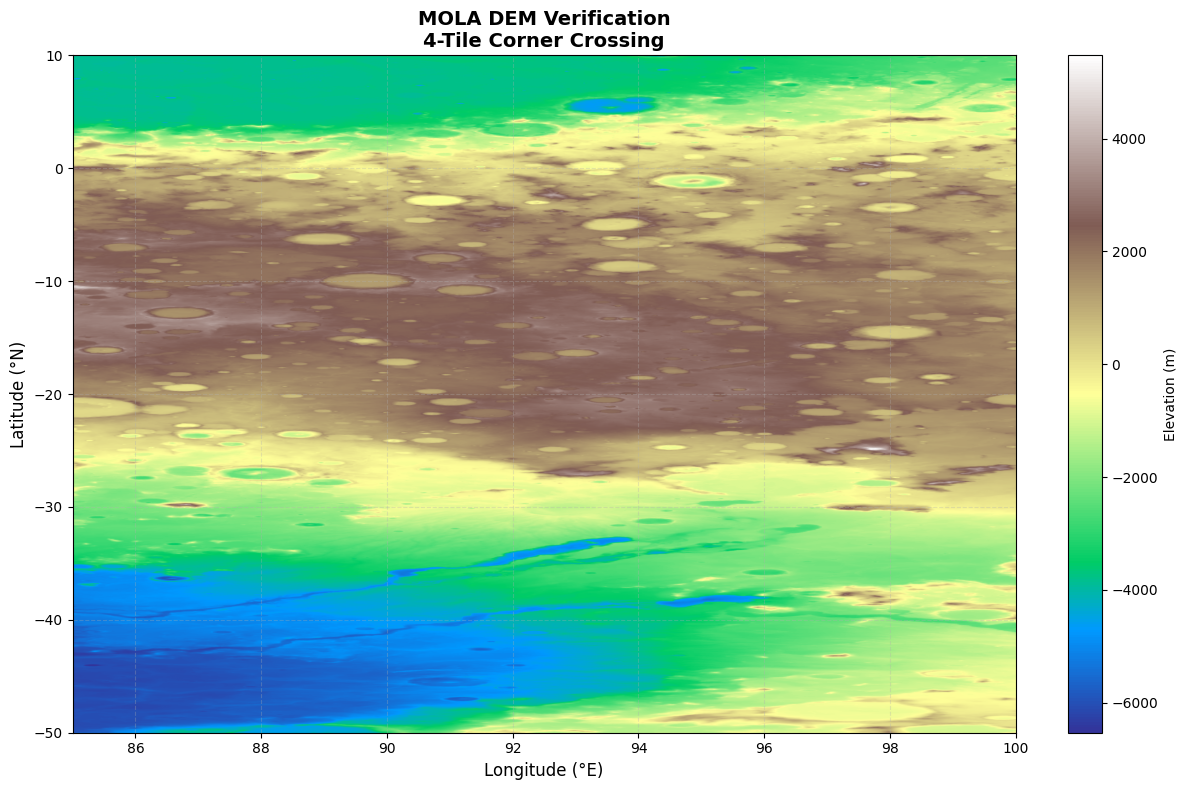


----------------------------------------------------------------------
TEST 5: Northern Hemisphere
----------------------------------------------------------------------
Latitude range:  (20, 40)
Longitude range: (200, 240)

GLOBAL MOLA MOSAIC READ
Requested latitude: 20.00 to 40.00
Requested longitude: 200.00 to 240.00

Intersecting tiles:
  megt44n180hb

Reading tile: megt44n180hb
  Lat range: 20.00 to 40.00
  Lon range: 200.00 to 240.00
  Shape: (2560, 5121)

FINAL STITCHED DEM
Shape: (2560, 5121)
Latitude range: 20.00 to 40.00
Longitude range: 200.00 to 240.00
Elevation range: -5136 to 14467 m

✓ DEM loaded successfully
  Shape: (2560, 5121)
  Latitude coverage: 20.00° to 40.00°
  Longitude coverage: 200.00° to 240.00°
  Elevation range: -5136 to 14467 m

Continuity checks:
  Latitude spacing continuous: True
  Longitude spacing continuous: True

  Plot saved: test_dem_5.png


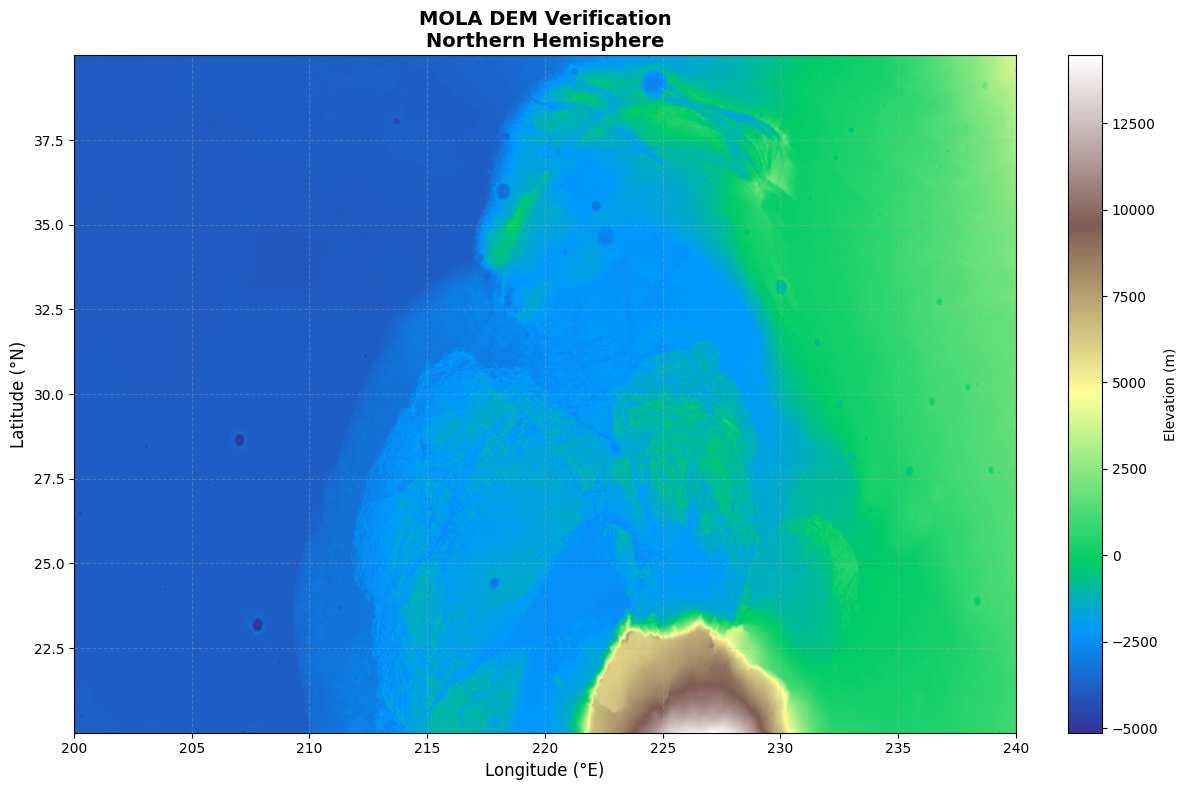


----------------------------------------------------------------------
TEST 6: Near Polar Region
----------------------------------------------------------------------
Latitude range:  (60, 80)
Longitude range: (250, 300)

GLOBAL MOLA MOSAIC READ
Requested latitude: 60.00 to 80.00
Requested longitude: 250.00 to 300.00

Intersecting tiles:
  megt88n180hb
  megt88n270hb

Reading tile: megt88n180hb
  Lat range: 60.00 to 80.00
  Lon range: 250.00 to 269.99
  Shape: (2560, 2560)

Reading tile: megt88n270hb
  Lat range: 60.00 to 80.00
  Lon range: 270.00 to 300.00
  Shape: (2560, 3841)

FINAL STITCHED DEM
Shape: (2560, 6400)
Latitude range: 60.00 to 80.00
Longitude range: 250.00 to 300.00
Elevation range: -5792 to -2342 m

✓ DEM loaded successfully
  Shape: (2560, 6400)
  Latitude coverage: 60.00° to 80.00°
  Longitude coverage: 250.00° to 300.00°
  Elevation range: -5792 to -2342 m

Continuity checks:
  Latitude spacing continuous: True
  Longitude spacing continuous: False

  Plot saved: 

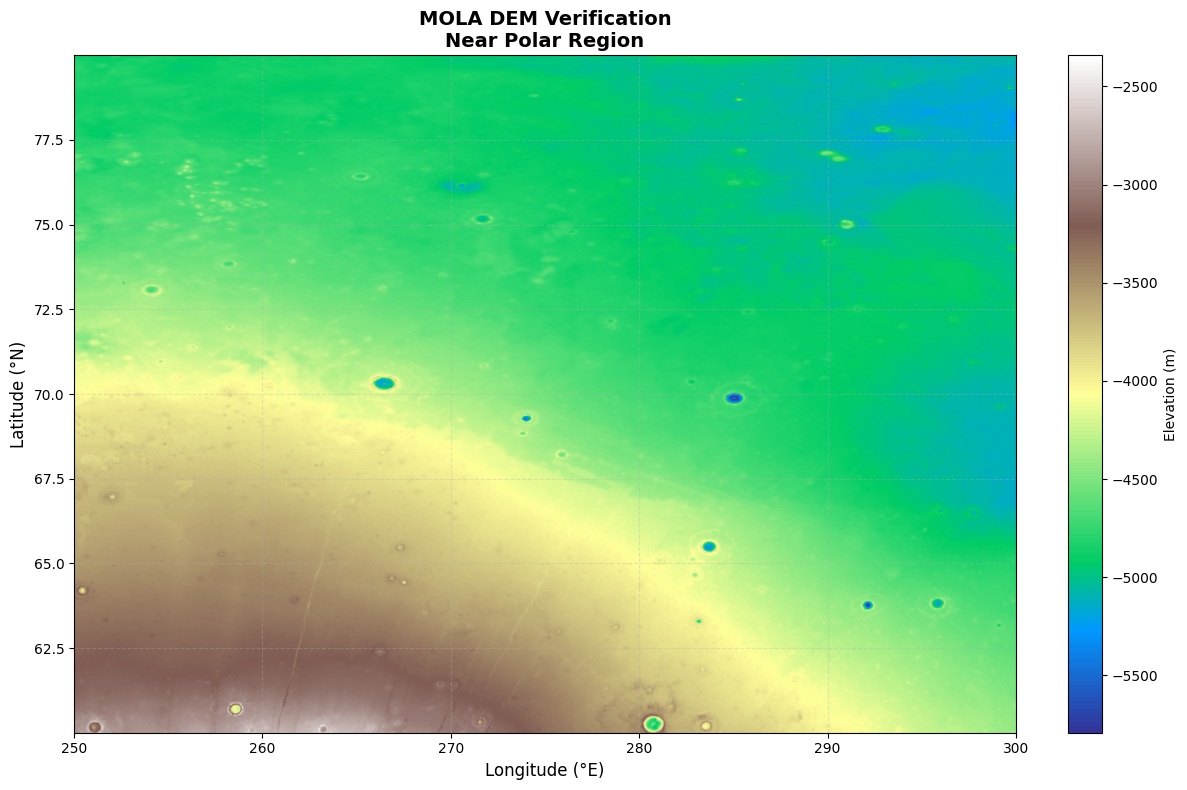


RANDOMIZED STRESS TESTS

Random Test 1
  Lat: -27.93 to -12.22
  Lon: 335.47 to 349.05

GLOBAL MOLA MOSAIC READ
Requested latitude: -27.93 to -12.22
Requested longitude: 335.47 to 349.05

Intersecting tiles:
  megt00n270hb

Reading tile: megt00n270hb
  Lat range: -27.93 to -12.22
  Lon range: 335.47 to 349.05
  Shape: (2011, 1739)

FINAL STITCHED DEM
Shape: (2011, 1739)
Latitude range: -27.93 to -12.22
Longitude range: 335.47 to 349.05
Elevation range: -3350 to 1436 m
  ✓ PASS (2011 × 1739)

Random Test 2
  Lat: -57.50 to -52.57
  Lon: 47.23 to 65.09

GLOBAL MOLA MOSAIC READ
Requested latitude: -57.50 to -52.57
Requested longitude: 47.23 to 65.09

Intersecting tiles:
  megt44s000hb

Reading tile: megt44s000hb
  Lat range: -57.50 to -52.57
  Lon range: 47.23 to 65.09
  Shape: (632, 2287)

FINAL STITCHED DEM
Shape: (632, 2287)
Latitude range: -57.50 to -52.57
Longitude range: 47.23 to 65.09
Elevation range: -5576 to 1337 m
  ✓ PASS (632 × 2287)

Random Test 3
  Lat: 14.01 to 18.34
  Lon

In [3]:
# ============================================================================
# 2. TEST GLOBAL MOLA DEM READER
# ============================================================================

print("\n" + "="*70)
print("2. TESTING GLOBAL MOLA DEM READER")
print("="*70)

mola_dir = data_dir / 'mola'

if mola_dir.exists():

    try:

        # ------------------------------------------------------------------
        # Initialize global reader
        # ------------------------------------------------------------------

        mola = MOLAReader(mola_dir)

        print("\n✓ Global MOLA reader initialized")

        # ------------------------------------------------------------------
        # TEST CASES
        # ------------------------------------------------------------------

        test_cases = [

            # --------------------------------------------------------------
            # Single tile
            # --------------------------------------------------------------

            {
                'name': 'Single Tile - Eastern Hellas',
                'lat_range': (-40, -35),
                'lon_range': (95, 115)
            },

            # --------------------------------------------------------------
            # Cross latitude tile boundary
            # --------------------------------------------------------------

            {
                'name': 'Latitude Boundary Crossing',
                'lat_range': (-50, -35),
                'lon_range': (95, 115)
            },

            # --------------------------------------------------------------
            # Cross longitude tile boundary
            # --------------------------------------------------------------

            {
                'name': 'Longitude Boundary Crossing',
                'lat_range': (-20, -10),
                'lon_range': (85, 100)
            },

            # --------------------------------------------------------------
            # Cross both latitude and longitude boundaries
            # --------------------------------------------------------------

            {
                'name': '4-Tile Corner Crossing',
                'lat_range': (-50, 10),
                'lon_range': (85, 100)
            },

            # --------------------------------------------------------------
            # Northern hemisphere
            # --------------------------------------------------------------

            {
                'name': 'Northern Hemisphere',
                'lat_range': (20, 40),
                'lon_range': (200, 240)
            },

            # --------------------------------------------------------------
            # Near polar region
            # --------------------------------------------------------------

            {
                'name': 'Near Polar Region',
                'lat_range': (60, 80),
                'lon_range': (250, 300)
            },
        ]

        # ------------------------------------------------------------------
        # RUN TESTS
        # ------------------------------------------------------------------

        for idx, test in enumerate(test_cases):

            print("\n" + "-"*70)
            print(f"TEST {idx+1}: {test['name']}")
            print("-"*70)

            lat_range = test['lat_range']
            lon_range = test['lon_range']

            print(f"Latitude range:  {lat_range}")
            print(f"Longitude range: {lon_range}")

            elevation, lats, lons = mola.read_elevation(
                lat_range,
                lon_range
            )

            print(f"\n✓ DEM loaded successfully")

            print(f"  Shape: {elevation.shape}")

            print(
                f"  Latitude coverage: "
                f"{lats.min():.2f}° to {lats.max():.2f}°"
            )

            print(
                f"  Longitude coverage: "
                f"{lons.min():.2f}° to {lons.max():.2f}°"
            )

            print(
                f"  Elevation range: "
                f"{elevation.min():.0f} "
                f"to "
                f"{elevation.max():.0f} m"
            )

            # --------------------------------------------------------------
            # Basic continuity checks
            # --------------------------------------------------------------

            lat_diff = np.diff(lats)
            lon_diff = np.diff(lons)

            lat_continuous = np.allclose(
                lat_diff,
                lat_diff[0],
                atol=1e-6
            )

            lon_continuous = np.allclose(
                lon_diff,
                lon_diff[0],
                atol=1e-6
            )

            print(f"\nContinuity checks:")

            print(
                f"  Latitude spacing continuous: "
                f"{lat_continuous}"
            )

            print(
                f"  Longitude spacing continuous: "
                f"{lon_continuous}"
            )

            # --------------------------------------------------------------
            # Plot DEM
            # --------------------------------------------------------------

            fig, ax = plt.subplots(figsize=(12, 8))

            im = ax.imshow(
                elevation,
                extent=[
                    lons.min(),
                    lons.max(),
                    lats.min(),
                    lats.max()
                ],
                cmap='terrain',
                aspect='auto',
                origin='upper'
            )

            plt.colorbar(
                im,
                ax=ax,
                label='Elevation (m)',
                fraction=0.046
            )

            ax.set_xlabel('Longitude (°E)', fontsize=12)
            ax.set_ylabel('Latitude (°N)', fontsize=12)

            ax.set_title(
                f"MOLA DEM Verification\n{test['name']}",
                fontsize=14,
                fontweight='bold'
            )

            ax.grid(True, alpha=0.3, linestyle='--')

            plt.tight_layout()

            save_path = (
                data_dir
                /
                'outputs'
                /
                f"test_dem_{idx+1}.png"
            )

            plt.savefig(
                save_path,
                dpi=150,
                bbox_inches='tight'
            )

            print(f"\n  Plot saved: {save_path.name}")

            plt.show()

        # ------------------------------------------------------------------
        # RANDOMIZED STRESS TESTS
        # ------------------------------------------------------------------

        print("\n" + "="*70)
        print("RANDOMIZED STRESS TESTS")
        print("="*70)

        np.random.seed(42)

        for i in range(5):

            lat_center = np.random.uniform(-80, 80)
            lon_center = np.random.uniform(0, 360)

            lat_half = np.random.uniform(2, 10)
            lon_half = np.random.uniform(2, 10)

            lat_range = (
                lat_center - lat_half,
                lat_center + lat_half
            )

            lon_range = (
                lon_center - lon_half,
                lon_center + lon_half
            )

            print(f"\nRandom Test {i+1}")

            print(
                f"  Lat: "
                f"{lat_range[0]:.2f} "
                f"to "
                f"{lat_range[1]:.2f}"
            )

            print(
                f"  Lon: "
                f"{lon_range[0]:.2f} "
                f"to "
                f"{lon_range[1]:.2f}"
            )

            try:

                elevation, lats, lons = mola.read_elevation(
                    lat_range,
                    lon_range
                )

                print(
                    f"  ✓ PASS "
                    f"({elevation.shape[0]} × "
                    f"{elevation.shape[1]})"
                )

            except Exception as e:

                print(f"  ✗ FAIL: {e}")

        print("\n" + "="*70)
        print("✓ GLOBAL MOLA VALIDATION COMPLETE")
        print("="*70)

    except Exception as e:

        print(f"\n✗ GLOBAL MOLA TEST FAILED:")
        print(f"  Error: {e}")

        import traceback
        traceback.print_exc()

else:

    print(f"\n✗ MOLA directory not found: {mola_dir}")